In [2]:
import sys
sys.path.append("../../..")
from utils.processing import json_file_access
from beir.datasets.data_loader import GenericDataLoader
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import pytrec_eval

c:\Users\marvi\.conda\envs\masterthesis\Lib\site-packages\beir\datasets\data_loader.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
rq1_ir_res = json_file_access("../../../05_results/rq1/results_rq1.json", "r")
corpus, queries, qrels = GenericDataLoader(data_folder="../../../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

  0%|          | 0/4635922 [00:00<?, ?it/s]

In [ ]:
results_rq1 = defaultdict(dict)

for key, value in rq1_ir_res.items():
    for query, result in value.items():
        results_rq1[key][query] = []
        for i, doc_id in enumerate(result.keys()):
            results_rq1[key][query].append(doc_id)

In [5]:
res_all = {}

configuration = {
    "cs_methods": ["LFMLocal", "GCE", "LocalTightnessExpansion"],
    "cs_core_node_number": [10,20,30]
}

# Iteratively add CS Top100
for cs in configuration["cs_methods"]:
    for cs_core_no in configuration["cs_core_node_number"]:
        res_all[cs + "_" + str(cs_core_no)] = json_file_access(f"../../../05_results/rq2/cs/kg2_results_rq2_cs_{cs}_{cs_core_no}_all_community.json","r")
res_all["RQ1" + "_" + str(0)] = results_rq1

In [5]:
evaluator = pytrec_eval.RelevanceEvaluator(qrels, {'recall.100000'})
recalls = defaultdict(dict)

for cs, cs_values in res_all.items():
    for ir_type, ir_values in cs_values.items():
        recall = 0.0
        fake_scores = defaultdict(dict)
        for query, docs in ir_values.items():
            for doc in docs:
                fake_scores[query][doc] = 0
        scores = evaluator.evaluate(fake_scores)
        for query_id in scores.keys():
            recall += scores[query_id]["recall_100000"]
        recall = recall / len(scores.keys())
        recalls[cs][ir_type] = recall

In [6]:
pd.DataFrame(recalls)

,LFMLocal_10,LFMLocal_20,LFMLocal_30,GCE_10,GCE_20,GCE_30,LocalTightnessExpansion_10,LocalTightnessExpansion_20,LocalTightnessExpansion_30,RQ1_0
boolean,0.201374,0.251153,0.284783,0.206108,0.255366,0.292904,0.199638,0.242530,0.277820,0.313695
bm25,0.268645,0.335885,0.382169,0.270572,0.344669,0.390251,0.257874,0.324726,0.373144,0.434605
vector,0.274083,0.342782,0.381598,0.279793,0.350785,0.390136,0.268577,0.324778,0.362732,0.425643
hybrid,0.313987,0.397858,0.458590,0.320758,0.404696,0.463936,0.302624,0.378519,0.437618,0.515497


## Calc Density of relevant Qrels in Graph

In [9]:
from utils.cs_pipeline import GraphCS
import networkit as nk
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, mode, norm

In [10]:
node_df = pd.read_parquet("../../../03_data/preprocessed_data/nodes_beir_dbpedia.parquet")
kg2_edges = pd.read_parquet('../../../03_data/preprocessed_data/wikilink_edges_beir_dbpedia.parquet')
Graph = GraphCS(node_df, kg2_edges)

Building Graph from given Data...
Graph built


In [9]:
density = {}
for query in qrels.keys():
    rel_nodes = [doc  for doc in qrels[query].keys() if qrels[query][doc]>0]
    subG = nk.graphtools.subgraphFromNodes(Graph.G, Graph._convert_dbpedia_to_index(rel_nodes))
    density[query] = nk.graphtools.density(subG)

In [10]:
def approximate_pdf(data):
    kde = gaussian_kde(data)
    x_values = np.linspace(data.min(), data.max(), 1000)  # Define x-axis range
    pdf_values = kde(x_values)
    mean = np.mean(data)
    median_value = np.median(data)
    mode_value = mode(data)[0]
    return x_values, pdf_values, mean, median_value, mode_value

In [11]:
x_values, pdf_values, mean, median_value, mode_value = approximate_pdf(np.array(list(density.values())))

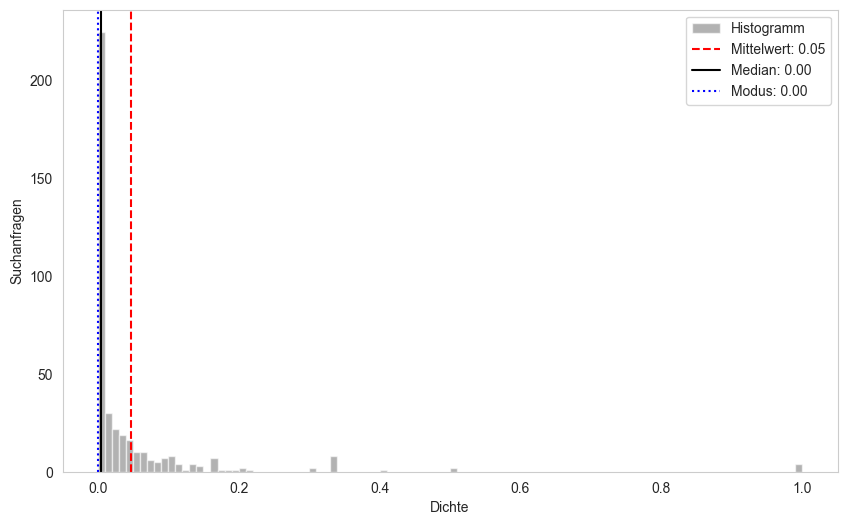

In [12]:
# Abbildung 34
plt.figure(figsize=(10,6))
plt.hist(np.array(list(density.values())), bins=100, density=False, alpha=0.6, color='gray', label='Histogramm')
plt.axvline(mean, color='r', linestyle='--', label=f'Mittelwert: {mean:.2f}')
plt.axvline(median_value, color='black', linestyle='-', label=f'Median: {median_value:.2f}')
plt.axvline(mode_value, color='b', linestyle=':', label=f'Modus: {mode_value:.2f}')
plt.xlabel("Dichte")
plt.ylabel("Suchanfragen")
plt.grid(False)
plt.legend()
plt.savefig("Abbildung_34.svg")

155


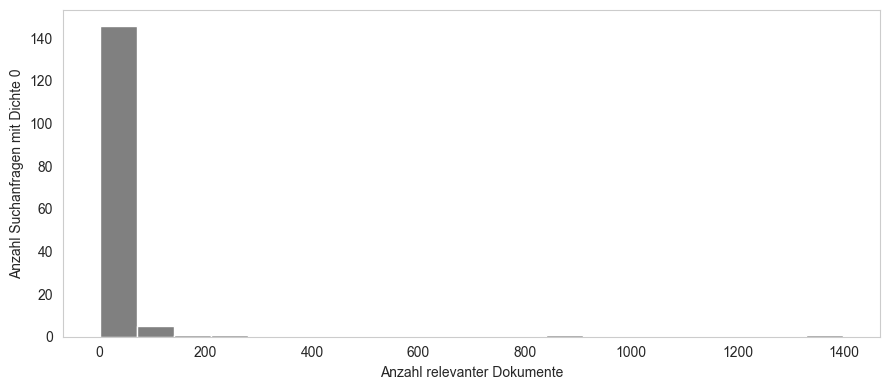

In [24]:
# Anhang B-36 
zero_dens = [key for key in density.keys() if density[key]==0.0]
print(len(zero_dens))
docs = []
for query, relevances in qrels.items():
    if query in zero_dens:
        relevance_counter = 0
        for doc in relevances.keys():
            if relevances[doc] > 0:
                relevance_counter += 1
        docs.append(relevance_counter)
plt.figure(figsize=(9,4))
plt.hist(docs, bins=20, color = "gray");
plt.xlabel("Anzahl relevanter Dokumente")
plt.ylabel("Anzahl Suchanfragen mit Dichte 0")
plt.grid(False)
plt.tight_layout()
plt.savefig("Anhang_B-36.svg")

In [11]:
import networkit as nk

In [12]:
mean_density = defaultdict(dict)
#for cs, cs_values in res_all.items():
for cs in ["GCE_10","GCE_20","GCE_30","LFMLocal_10","LFMLocal_20","LFMLocal_30","LocalTightnessExpansion_10","LocalTightnessExpansion_20","LocalTightnessExpansion_30"]:
    #for ir_type, ir_values in cs_values.items():
    for ir_type in ["boolean", "bm25","vector","hybrid"]:
        mean_density[cs][ir_type] = []
        for query, docs in res_all[cs][ir_type].items():
            subG = nk.graphtools.subgraphFromNodes(Graph.G, Graph._convert_dbpedia_to_index(docs))
            mean_density[cs][ir_type].append(nk.graphtools.density(subG))
        print(cs, ir_type, np.mean(mean_density[cs][ir_type]))

GCE_10 boolean 0.046544030476014076
GCE_10 bm25 0.0459675197745108
GCE_10 vector 0.04210791946909213
GCE_10 hybrid 0.04360530774104694
GCE_20 boolean 0.025295504389269145
GCE_20 bm25 0.024514267891738127
GCE_20 vector 0.02351996747181024
GCE_20 hybrid 0.02420527570349856
GCE_30 boolean 0.017904357128464887
GCE_30 bm25 0.01701422800915607
GCE_30 vector 0.01617703922285164
GCE_30 hybrid 0.016845023641625212
LFMLocal_10 boolean 0.047369023332728855
LFMLocal_10 bm25 0.046536529572821554
LFMLocal_10 vector 0.043296573192801134
LFMLocal_10 hybrid 0.04435882824771385
LFMLocal_20 boolean 0.026085041126562316
LFMLocal_20 bm25 0.025097026266713854
LFMLocal_20 vector 0.024115521564016158
LFMLocal_20 hybrid 0.02468128775860049
LFMLocal_30 boolean 0.01846185942408526
LFMLocal_30 bm25 0.01740148510633615
LFMLocal_30 vector 0.016751746688928485
LFMLocal_30 hybrid 0.017182745821569756
LocalTightnessExpansion_10 boolean 0.04569515268112253
LocalTightnessExpansion_10 bm25 0.04574333996826317
LocalTightn